In [2]:
device = "cuda"

In [3]:
import torch
torch.cuda.is_available()

True

In [4]:
import numpy as np 
import pandas as pd
import matplotlib as plt 
import seaborn as sns

In [5]:
dataset = pd.read_csv("Churn_Modelling.csv")

In [6]:
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Problem statement
- Weather the customer will stay or exit the company in the furure, so we need to prevent the leakage of the customers by providing more services to them.
- It is a binary classification problem

In [7]:
# Find the features and target variables 
X = dataset.iloc[:,3:13]
Y = dataset.iloc[:,13]

In [8]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [9]:
Y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [56]:
# Preserve the column titles 
feature_names = X.columns

# Check class imbalance 
The dataset is mild imbalanced there are 7963 (79%) customers not exit from the bank and 2037 (20%) exited from the bank. which is 3.9 : 1. To make this balance we apply SMOT technique after train test split why we applying SMOT after slpit because the test data should remain unchnaged.

In [10]:
print(Y.value_counts())
print(Y.value_counts(normalize=True) * 100)

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


# Feature Engineering
- Since the feature variables contain categorical information lets apply Onehot encoding.

In [11]:
from sklearn.preprocessing import OneHotEncoder
Geography = pd.get_dummies(X['Geography'],drop_first=True).astype(int)
Gender = pd.get_dummies(X['Gender']).astype(int)

In [12]:
Gender

,Female,Male
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0
...,...,...
9995,0,1
9996,0,1
9997,1,0
9998,0,1


In [13]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [14]:
# drop 'Geography','Gender' from X and concatinate with onehot values 
X = X.drop(['Geography', 'Gender'], axis = 1)
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64
9996,516,35,10,57369.61,1,1,1,101699.77
9997,709,36,7,0.00,1,0,1,42085.58
9998,772,42,3,75075.31,2,1,0,92888.52


In [15]:
X = pd.concat([X, Geography, Gender], axis=1)
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Female,Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,1,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,1,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,1,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,0,0,1,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0,0,1


In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

# Feature Scaling

In [18]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


# Apply SMOTE

In [19]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=0)
X_train_res, Y_train_res = sm.fit_resample(X_train, Y_train)

# Check result
print("Before SMOTE:", X_train.shape)
print("After SMOTE:", X_train_res.shape)

Before SMOTE: (8000, 12)
After SMOTE: (12712, 12)


In [ ]:
# Preserve the column titles
feature_names = [f'Feature_{i}' for i in range(X_train_res.shape[1])]

# Lets create ANN


In [85]:
import torch
import torch.nn as nn
nn.Sequential
nn.Linear(12, 64)
nn.LeakyReLU()
nn.PReLU()
nn.ELU()
nn.Dropout(p=0.2)

Dropout(p=0.2, inplace=False)

In [86]:
# Let's Initialize ANN
Classifier = nn.Sequential()

In [87]:
# Define dropout 
dropout = nn.Dropout()

In [88]:
# Adding the input layer 
Classifier.add_module('Layer1',nn.Linear(12,64))
Classifier.add_module('relu1', nn.ReLU())

In [89]:
# Adding the 1st hidden layer 
Classifier.add_module('Layer2',nn.Linear(64,32))
Classifier.add_module('Relu2',nn.ReLU())
Classifier.add_module('dropout',nn.Dropout())

In [90]:
# Adding the 2st hidden layer 
Classifier.add_module('Layer3',nn.Linear(32, 16))
Classifier.add_module('Relu3',nn.ReLU())
Classifier.add_module('dropout',nn.Dropout())

In [91]:
# Adding the output layer
Classifier.add_module('output',nn.Linear(16,1))

In [92]:
import torch.nn as nn
criterion = nn.BCEWithLogitsLoss()

In [93]:
import torch.optim as optim

optimizer = optim.Adam(Classifier.parameters(), lr=0.001)

In [99]:
import torch

X_train_ten = torch.tensor(X_train_res.values, dtype=torch.float32)
Y_train_ten = torch.tensor(Y_train_res.values, dtype=torch.float32).view(-1, 1)

X_test_ten = torch.tensor(X_test.values, dtype=torch.float32)
Y_test_ten = torch.tensor(Y_test.values, dtype=torch.float32).view(-1, 1)


print(type(X_train_ten))
print(type(Y_train_ten))
print(type(X_test_ten))
print(type(Y_test_ten))

<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>


# Impliment early stopping and trining
- At some point, the accuracy stop increasing, By implimenting the early stopping when the accuracy is not increasing. then the training will automatically get stopped.

In [100]:
# Early stopping 
best_val_loss = float('inf')
patience = 40
counter = 0

In [101]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies= []

In [102]:
    # weight updattion
pos_weight = torch.tensor([6356/1644], dtype=torch.float32).to(X_train_ten.device)
criterion = nn.BCEWithLogitsLoss()

In [103]:
for epoch in range(1000):
    Classifier.train()

    # Forward pass
    outputs = Classifier(X_train_ten)

    # Loss
    Loss = criterion(outputs, Y_train_ten)

    # Backward pass
    optimizer.zero_grad()
    Loss.backward()
    optimizer.step()

    # Accuracy
    probs = torch.sigmoid(outputs)
    preds = (probs >= 0.4).float()
    accuracy = (preds == Y_train_ten).float().mean()

    #Validation
    Classifier.eval()
    with torch.no_grad():
        val_outputs = Classifier(X_test_ten)
        val_loss = criterion(val_outputs, Y_test_ten)

        val_probs = torch.sigmoid(val_outputs)
        val_preds = (val_probs >= 0.4).float()
        val_accuracy = (val_preds == Y_test_ten).float().mean()

    Classifier.train()
    # Early Stopping
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        counter = 0
        torch.save(Classifier.state_dict(), "best_model.pth")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

    # Model History
    train_losses.append(Loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(accuracy.item())
    val_accuracies.append(val_accuracy.item())

    print(f"Epoch {epoch}, Loss: {Loss:.4f}, Val Loss: {val_loss:.4f}, Acc: {accuracy:.4f}")


Epoch 0, Loss: nan, Val Loss: nan, Acc: 0.5000
Epoch 1, Loss: nan, Val Loss: nan, Acc: 0.5000
Epoch 2, Loss: nan, Val Loss: nan, Acc: 0.5000
Epoch 3, Loss: nan, Val Loss: nan, Acc: 0.5000
Epoch 4, Loss: nan, Val Loss: nan, Acc: 0.5000
Epoch 5, Loss: nan, Val Loss: nan, Acc: 0.5000
Epoch 6, Loss: nan, Val Loss: nan, Acc: 0.5000
Epoch 7, Loss: nan, Val Loss: nan, Acc: 0.5000
Epoch 8, Loss: nan, Val Loss: nan, Acc: 0.5000
Epoch 9, Loss: nan, Val Loss: nan, Acc: 0.5000
Epoch 10, Loss: nan, Val Loss: nan, Acc: 0.5000
Epoch 11, Loss: nan, Val Loss: nan, Acc: 0.5000
Epoch 12, Loss: nan, Val Loss: nan, Acc: 0.5000
Epoch 13, Loss: nan, Val Loss: nan, Acc: 0.5000
Epoch 14, Loss: nan, Val Loss: nan, Acc: 0.5000
Epoch 15, Loss: nan, Val Loss: nan, Acc: 0.5000
Epoch 16, Loss: nan, Val Loss: nan, Acc: 0.5000
Epoch 17, Loss: nan, Val Loss: nan, Acc: 0.5000
Epoch 18, Loss: nan, Val Loss: nan, Acc: 0.5000
Epoch 19, Loss: nan, Val Loss: nan, Acc: 0.5000
Epoch 20, Loss: nan, Val Loss: nan, Acc: 0.5000
Ep

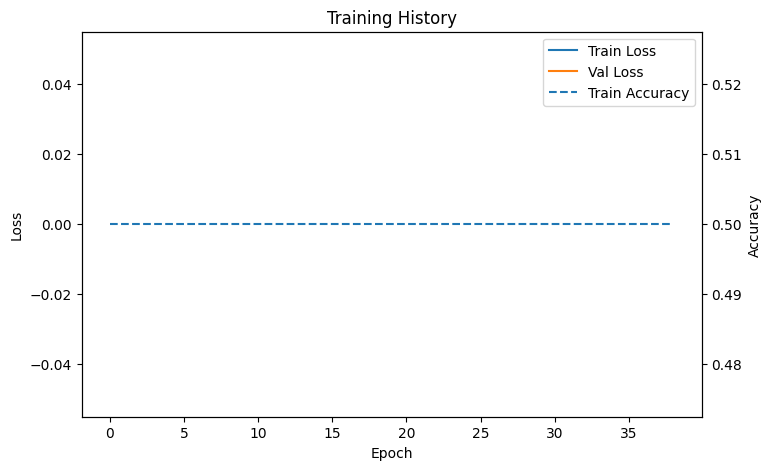

In [104]:
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(figsize=(8,5))

# Loss axis
ax1.plot(train_losses, label="Train Loss")
ax1.plot(val_losses, label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

# Accuracy axis
ax2 = ax1.twinx()
ax2.plot(train_accuracies, linestyle='--', label="Train Accuracy")
ax2.set_ylabel("Accuracy")

# Legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2)

plt.title("Training History")
plt.show()

Since, I have been using ANN and PyTorch which dont have a built in feature importance I used Random forest and Gradient boosting as surrogate models
surrogate models - Which are simple and interpreteble models used to interpret and explain the complex models.
We are comparing 4 importance methods.
* RF Tree based
* RF Permutation 
* GB Tree based 
* GB Permutation

Checking on SMOTE Data 

In [105]:
from sklearn.ensemble import RandomForestClassifier

# Initialize 
rf_model = RandomForestClassifier(random_state=42)


In [106]:
# Train on Training data (SMOTE data)
rf_model.fit(X_train_res, Y_train_res)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [107]:
gb_model.fit(X_train_res, Y_train_res)

ValueError: Input X contains NaN.
GradientBoostingClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

           Feature  Importance
0      CreditScore         0.0
1              Age         0.0
2           Tenure         0.0
3          Balance         0.0
4    NumOfProducts         0.0
5        HasCrCard         0.0
6   IsActiveMember         0.0
7  EstimatedSalary         0.0
8          Germany         0.0
9            Spain         0.0


In [ ]:
X_test = pd.DataFrame(X_test, columns=feature_names)
perm_result = permutation_importance(
    rf_model,          # or gb_model
    X_test,
    Y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Predicting the test set result

In [36]:

with torch.no_grad():
    outputs = Classifier(X_test_ten)
    probs = torch.sigmoid(outputs)

In [37]:
preds = (probs >= 0.6).float()
Y_test_ten = Y_test_ten.reshape(-1)

In [38]:
preds = preds.cpu().numpy()

In [39]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(Y_test_ten, preds))
print(confusion_matrix(Y_test_ten, preds))

              precision    recall  f1-score   support

         0.0       0.91      0.86      0.88      1607
         1.0       0.52      0.64      0.58       393

    accuracy                           0.81      2000
   macro avg       0.71      0.75      0.73      2000
weighted avg       0.83      0.81      0.82      2000

[[1374  233]
 [ 140  253]]


In [40]:
for t in [0.4, 0.5, 0.6, 0.7]:
    preds = (probs >= t).float()
    print(f"\nThreshold: {t}")
    print(classification_report(Y_test, preds))


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.93      0.73      0.82      1607
           1       0.41      0.77      0.54       393

    accuracy                           0.74      2000
   macro avg       0.67      0.75      0.68      2000
weighted avg       0.83      0.74      0.76      2000


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.92      0.81      0.86      1607
           1       0.48      0.72      0.57       393

    accuracy                           0.79      2000
   macro avg       0.70      0.76      0.72      2000
weighted avg       0.83      0.79      0.80      2000


Threshold: 0.6
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      1607
           1       0.52      0.66      0.58       393

    accuracy                           0.82      2000
   macro avg       0.72      0.76      0.73      2000
weighted avg       0.84   

In [41]:
# Applying the highest threshold to the model which is 0.7


In [42]:
preds = (probs >= 0.7).float()
Y_test_ten = Y_test_ten.reshape(-1)

In [43]:
preds = preds.cpu().numpy()

In [44]:
print(classification_report(Y_test_ten, preds))
print(confusion_matrix(Y_test_ten, preds))

              precision    recall  f1-score   support

         0.0       0.90      0.91      0.90      1607
         1.0       0.61      0.59      0.60       393

    accuracy                           0.85      2000
   macro avg       0.76      0.75      0.75      2000
weighted avg       0.84      0.85      0.84      2000

[[1462  145]
 [ 163  230]]


In [45]:
# To view the updated weights
print(Classifier.Layer1.weight)

Parameter containing:
tensor([[ 2.6070e-02,  1.2461e-02,  6.0604e-02, -6.9352e-02, -3.9532e-01,
         -1.1516e-02, -4.2805e-02,  6.7515e-02, -3.3125e-02, -1.2855e-01,
         -8.9038e-02, -2.2387e-01],
        [-2.6569e-01,  7.8707e-02,  1.6493e-01, -3.3801e-01, -3.3699e-01,
          1.6826e-01, -3.2823e-01, -1.4238e-01, -8.5608e-02,  1.4971e-01,
         -3.0801e-01,  1.8228e-01],
        [ 4.8872e-02,  1.8762e-01, -4.0313e-03,  2.5576e-01,  1.8059e-01,
          7.7509e-02, -2.3239e-01, -7.7867e-02,  2.0053e-01,  2.3232e-01,
          3.1755e-01, -7.6077e-03],
        [-1.7497e-01,  1.7700e-01, -5.2566e-02,  1.3446e-02, -3.3427e-01,
          2.1646e-01, -3.0623e-01, -4.5208e-02, -1.6283e-01, -9.6750e-02,
         -1.4626e-01,  8.4563e-02],
        [-2.1144e-01, -9.8377e-02, -5.6846e-02,  3.1651e-01, -2.8549e-01,
          2.2774e-01,  1.1585e-01,  2.8071e-01, -3.2029e-02, -5.4945e-01,
          1.4509e-01, -2.1194e-01],
        [ 1.7453e-02,  4.5947e-02, -6.0272e-02,  2.9937e-0

In [46]:
# Improvments
# Apply logistic regression
# Apply random forest
# Apply ROC curve